In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# (6, 2)
X = np.array([
    [1, 1],
    [1, 2],
    [2, 1],

    [4, 4],
    [4, 5],
    [5, 4],
])

# target: (6, )
y = np.array([
    -1, -1, -1,
     1,  1,  1
])


In [6]:
X[y==1, 1]

array([4, 5, 4])

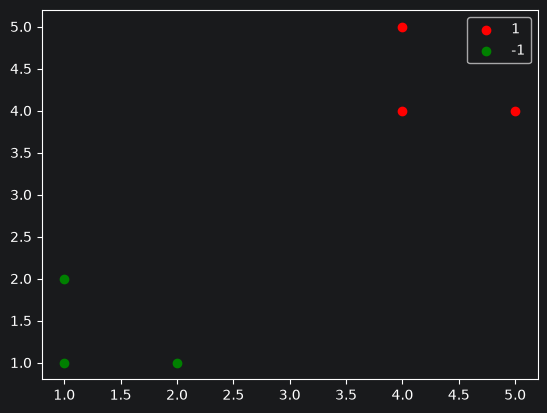

In [7]:
plt.scatter(X[y==1, 0], X[y==1, 1], color="red", label="1")
plt.scatter(X[y==-1, 0], X[y==-1, 1], color="green", label="-1")
plt.legend()
plt.show()

In [9]:
from sklearn.svm import SVC

In [ ]:
model = SVC(kernel="linear", C=1.0)
model.fit(X, y);

In [10]:
print(model.coef_)
print(model.intercept_)
print(model.support_vectors_)

[[0.39986345 0.40009103]]
[-2.19989379]
[[1. 2.]
 [2. 1.]
 [4. 4.]]


In [12]:
# min_pos = min(X[:, 0]), min(X[:, 1])
# max_pos = max(X[:, 0]), max(X[:, 1])
#
# def linear_func(x1, x2):
#     return x1*model.coef_ + x2*model.coef_ + model.intercept_
#
# linear_func(min_pos[0], min_pos[1])
#
# plt.scatter(X[y==1, 0], X[y==1, 1], color="red", label="1")
# plt.scatter(X[y==-1, 0], X[y==-1, 1], color="green", label="-1")
# plt.plot([linear_func(min_pos[0], min_pos[1])], )
# plt.legend()
# plt.show()

array([[-1.40016689, -1.39971173]])

In [13]:
w1 = model.coef_[0, 0]
w2 = model.coef_[0, 1]
b = model.intercept_[0]

def boundary(x1):
    return -(w1 * x1 + b) / w2

min_x1 = min(X[:, 0])
max_x1 = max(X[:, 0])

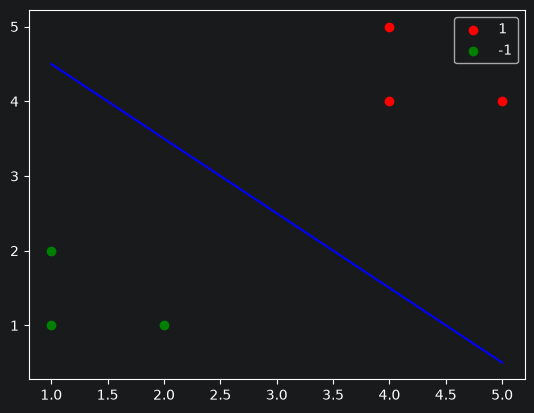

In [16]:
plt.scatter(X[y==1, 0], X[y==1, 1], color="red", label="1")
plt.scatter(X[y==-1, 0], X[y==-1, 1], color="green", label="-1")
plt.plot([min_x1, max_x1], [boundary(min_x1), boundary(max_x1)], color="blue")
plt.legend()
plt.show()

In [18]:
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=100,
    n_features=5,
    n_informative=3,
    n_redundant=0,
    n_classes=2,
    class_sep=1.0,
    random_state=42
)

print(X.shape)
print(X[:5])
print(y.shape)
print(y[:5])

(100, 5)
[[ 0.05144816 -0.15993853 -1.16920773  0.85765962 -0.01644241]
 [ 2.68984314  0.54336019  3.53580658 -1.66940528 -1.56209771]
 [-2.47076849 -0.50694318 -0.79409679  0.24496657  1.07438287]
 [ 1.6209367  -1.2110162   0.69947048 -0.0660798   0.16673293]
 [-1.45676161 -0.2209696   0.19891555 -0.11232805 -0.76633981]]
(100,)
[0 1 0 1 0]


In [19]:
from sklearn.model_selection import train_test_split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size=0.7,
    random_state=42
)

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_standard = scaler.fit_transform(X_train)
model = SVC(kernel="linear", C=1.0)

model.fit(X_train_standard, y_train);

In [35]:
model.score(X_train_standard, y_train)

0.9571428571428572

In [36]:
X_test_standard = scaler.transform(X_test)

model.score(X_test_standard, y_test)

0.9333333333333333

In [40]:
from sklearn.pipeline import Pipeline

for k_type in ["linear", "rbf"]:
    print(f" --- {k_type} --- ")
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel=k_type, C=1.0))
    ])

    print(model.fit(X_train, y_train))
    print(model.score(X_train, y_train))
    print(model.score(X_test, y_test))

 --- linear --- 
Pipeline(steps=[('scaler', StandardScaler()), ('svc', SVC(kernel='linear'))])
0.9571428571428572
0.9333333333333333
 --- rbf --- 
Pipeline(steps=[('scaler', StandardScaler()), ('svc', SVC())])
0.9571428571428572
0.8333333333333334


In [41]:
for gamma in [0.01, 0.1, 1, 10]:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(
            kernel="rbf",
            C=1.0,
            gamma=gamma
        ))
    ])

    model.fit(X_train, y_train)

    print(
        gamma,
        model.score(X_train, y_train),
        model.score(X_test, y_test)
    )


0.01 0.8571428571428571 0.8
0.1 0.9142857142857143 0.8333333333333334
1 1.0 0.9
10 1.0 0.4666666666666667
